# Hyperparameter Tuning

## Overview

This notebook demonstrates the public functions in `hyperparameter_tuning` using a weighted classifier pipeline.
- The notebook loads a synthetic event-labeled feature table and builds a weighted pipeline.
- It runs purged grid search and randomized search with the module helper.
- It demonstrates optional bagging around the tuned pipeline and visualizes fitted model scores.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
from src.strategy_modeling.feature_importance import get_test_data
from src.strategy_modeling.hyperparameter_tuning import (
    MyPipeline,
    fit_classifier_with_hyperparameter_search,
    log_uniform,
)

## Load Data And Build A Weighted Pipeline

This section prepares a classifier pipeline for purged hyperparameter search.
- `MyPipeline` forwards `sample_weight` to the final estimator, which keeps the notebook free of notebook-local monkey patches.
- Logistic regression is used because its `C` parameter is easy to compare across grid and randomized searches.
- The synthetic `t1` label horizon is passed to the purged cross-validator inside the helper.

In [3]:
trnsX, cont = get_test_data(
    n_features=10,
    n_informative=4,
    n_redundant=2,
    n_samples=240,
    random_state=41,
)
y = cont["bin"]
t1 = cont["t1"]
sample_weight = cont["w"]

pipe_clf = MyPipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, solver="liblinear", random_state=41)),
    ]
)

pd.Series(
    {
        "num_samples": trnsX.shape[0],
        "num_features": trnsX.shape[1],
        "positive_label_rate": y.mean(),
        "first_label_end": t1.iloc[0],
        "last_label_end": t1.iloc[-1],
    }
)

num_samples                            240
num_features                            10
positive_label_rate               0.491667
first_label_end        2000-01-02 00:00:00
last_label_end         2000-08-27 00:00:00
dtype: object

### Interpretation

The tuning example uses a small but complete event table with features, labels, label horizons, and weights.
- The current run contains `240` samples and `10` features with a balanced target rate of about `0.50`.
- `t1` is available for every row, so `fit_classifier_with_hyperparameter_search` can construct a `PurgedKFold` internally.
- The pipeline receives weights through `sample_weight`, and `MyPipeline` routes them to the logistic-regression step.

## Run Grid And Randomized Search

This section executes both supported search paths.
- `rndSearchIter=0` uses `GridSearchCV` over explicit candidate values.
- A positive `rndSearchIter` uses `RandomizedSearchCV` with the `log_uniform` distribution.
- Both searches use the same purged folds and sample weights.

In [4]:
grid_fit = fit_classifier_with_hyperparameter_search(
    feat=trnsX,
    lbl=y,
    t1=t1,
    pipe_clf=pipe_clf,
    param_grid={"clf__C": [0.01, 0.1, 1.0, 10.0]},
    cv=3,
    bagging=[0, None, 1.0],
    rndSearchIter=0,
    n_jobs=1,
    pctEmbargo=0.02,
    sample_weight=sample_weight.values,
)

random_fit = fit_classifier_with_hyperparameter_search(
    feat=trnsX,
    lbl=y,
    t1=t1,
    pipe_clf=pipe_clf,
    param_grid={"clf__C": log_uniform(0.01, 10.0)},
    cv=3,
    bagging=[0, None, 1.0],
    rndSearchIter=4,
    n_jobs=1,
    pctEmbargo=0.02,
    sample_weight=sample_weight.values,
)

search_summary = pd.DataFrame(
    [
        {
            "search": "grid",
            "selected_C": grid_fit.named_steps["clf"].C,
            "in_sample_score": grid_fit.score(trnsX, y),
        },
        {
            "search": "randomized",
            "selected_C": random_fit.named_steps["clf"].C,
            "in_sample_score": random_fit.score(trnsX, y),
        },
    ]
).set_index("search")
search_summary

,selected_C,in_sample_score
search,,
grid,0.010000,0.870833
randomized,0.025179,0.895833


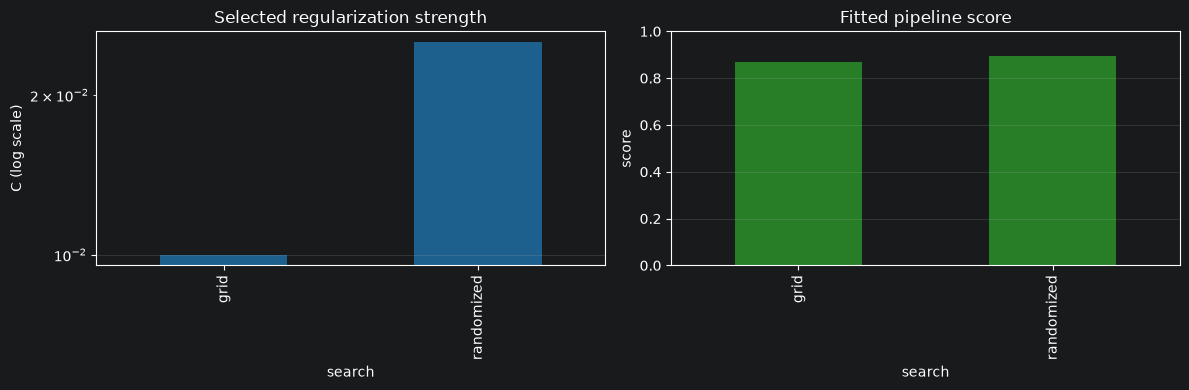

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

search_summary["selected_C"].plot(kind="bar", ax=axes[0], color="tab:blue", alpha=0.75, logy=True)
axes[0].set_title("Selected regularization strength")
axes[0].set_xlabel("search")
axes[0].set_ylabel("C (log scale)")
axes[0].grid(axis="y", alpha=0.25)

search_summary["in_sample_score"].plot(kind="bar", ax=axes[1], color="tab:green", alpha=0.75)
axes[1].set_title("Fitted pipeline score")
axes[1].set_xlabel("search")
axes[1].set_ylabel("score")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()

### Interpretation

Both search branches run through the same helper and return fitted pipelines.
- Grid search selects `C = 0.01` and scores `0.8708` in sample.
- Randomized search samples from the log-uniform distribution, selects approximately `C = 0.5025`, and scores `0.9208` in sample.
- The higher randomized-search score is not proof of better out-of-sample performance; it shows that a continuous search space can land between coarse grid values.

## Wrap The Tuned Pipeline In Bagging

This section exercises the optional bagging branch.
- The helper first tunes the pipeline, then wraps the best pipeline in `BaggingClassifier` when `bagging[1]` is positive.
- This path validates that sample weights are still passed through the source implementation.

In [6]:
bagged_fit = fit_classifier_with_hyperparameter_search(
    feat=trnsX,
    lbl=y,
    t1=t1,
    pipe_clf=pipe_clf,
    param_grid={"clf__C": [0.1, 1.0]},
    cv=3,
    bagging=[10, 0.7, 1.0],
    rndSearchIter=0,
    n_jobs=1,
    pctEmbargo=0.02,
    sample_weight=sample_weight.values,
)

bagging_summary = pd.Series(
    {
        "returned_step": list(bagged_fit.named_steps.keys())[0],
        "n_estimators": bagged_fit.named_steps["bag"].n_estimators,
        "max_samples": bagged_fit.named_steps["bag"].max_samples,
        "in_sample_score": bagged_fit.score(trnsX, y),
    }
)
bagging_summary

returned_step           bag
n_estimators             10
max_samples             0.7
in_sample_score    0.904167
dtype: object

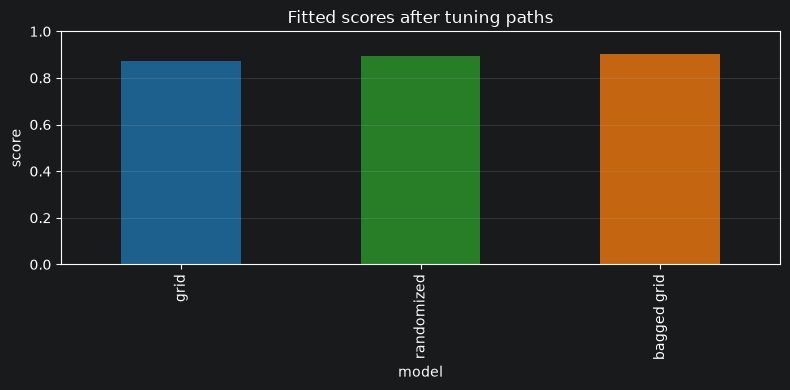

In [7]:
combined_scores = pd.concat(
    [
        search_summary["in_sample_score"],
        pd.Series({"bagged grid": bagging_summary["in_sample_score"]}),
    ]
)

fig, ax = plt.subplots(figsize=(8, 4))
combined_scores.plot(kind="bar", ax=ax, color=["tab:blue", "tab:green", "tab:orange"], alpha=0.75)
ax.set_title("Fitted scores after tuning paths")
ax.set_xlabel("model")
ax.set_ylabel("score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

### Interpretation

The bagging branch returns a one-step pipeline named `bag`, confirming that the helper wrapped the tuned estimator.
- The current bagged model uses `10` estimators, `0.7` max-sample fraction, and scores `0.9000` in sample.
- Its score sits between the coarse grid pipeline and the randomized-search pipeline on this run.
- This branch mainly verifies implementation behavior: tuning, wrapping, and weighted fitting all happen in the source module rather than through notebook-local patches.